Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: c:\Users\Madhav\AppData\Local\Programs\Python\Python310\lib\site-packages\lpips\weights\v0.1\vgg.pth
LPIPS loaded successfully.
Saved base image: 1404x936
Evaluated JPEG_Q10:   44.5 KB | PSNR: 25.69 dB
Evaluated JPEG_Q20:   68.5 KB | PSNR: 27.45 dB
Evaluated JPEG_Q30:   94.5 KB | PSNR: 28.49 dB
Evaluated JPEG_Q40:  118.6 KB | PSNR: 29.22 dB
Evaluated JPEG_Q50:  141.9 KB | PSNR: 29.83 dB
Evaluated JPEG_Q70:  206.3 KB | PSNR: 31.28 dB
Evaluated JPEG_Q90:  433.4 KB | PSNR: 34.78 dB
Saved to results/jpeg_metrics.csv
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: c:\Users\Madhav\AppData\Local\Programs\Python\Python310\lib\site-packages\lpips\weights\v0.1\vgg.pth
LPIPS loaded successfully.


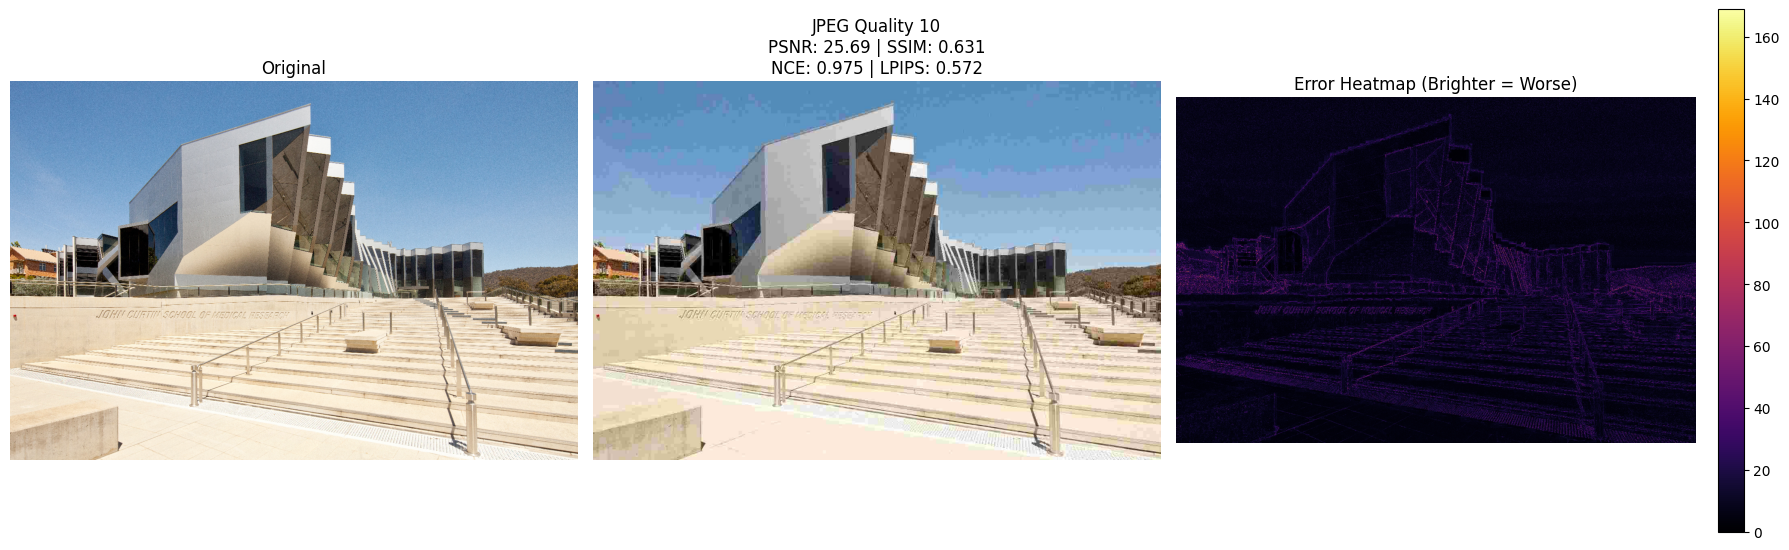

In [2]:
# CELL 1: Imports
import cv2
import os
import time
import pandas as pd
from utils import MetricsEngine, visual_compare

# CELL 2: Setup Baseline Generator
def run_jpeg_experiments(image_path="jcsmr-1.jpg", downscale_factor=1):
    engine = MetricsEngine()
    results = []
    
    # Load and downscale
    img_raw = cv2.imread(image_path)
    h, w = img_raw.shape[:2]
    new_w, new_h = w // downscale_factor, h // downscale_factor
    img_down = cv2.resize(img_raw, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    
    # Save the Ground Truth
    true_rgb = cv2.cvtColor(img_down, cv2.COLOR_BGR2RGB)
    true_img_path = "images/original_downscaled.png" # PNG is lossless!
    cv2.imwrite(true_img_path, img_down)
    print(f"Saved base image: {new_w}x{new_h}")
    
    # The Qualities we want to test
    qualities = [10, 20, 30, 40, 50, 70, 90]
    
    for q in qualities:
        method_name = f"JPEG_Q{q}"
        save_path = f"images/{method_name}.jpg"
        
        # 1. Save File (Compress)
        cv2.imwrite(save_path, img_down, [int(cv2.IMWRITE_JPEG_QUALITY), q])
        size_kb = os.path.getsize(save_path) / 1024.0
        
        # 2. Measure Latency (Decompress)
        start_time = time.time()
        decoded_bgr = cv2.imread(save_path)
        latency = (time.time() - start_time) * 1000 # MS
        
        # 3. Calculate Metrics
        decoded_rgb = cv2.cvtColor(decoded_bgr, cv2.COLOR_BGR2RGB)
        metrics = engine.compute_all(true_rgb, decoded_rgb)
        
        # 4. Log
        row = {"Method": method_name, "Size_KB": size_kb, "Latency_ms": latency}
        row.update(metrics)
        results.append(row)
        
        print(f"Evaluated {method_name}: {size_kb:>6.1f} KB | PSNR: {metrics['PSNR']:.2f} dB")
        
    df = pd.DataFrame(results)
    df.to_csv("results/jpeg_metrics.csv", index=False)
    print("Saved to results/jpeg_metrics.csv")
    return df

# CELL 3: Run the baseline
jpeg_df = run_jpeg_experiments("jcsmr-1.jpg", downscale_factor=4)

# CELL 4: Visual Check
# Let's compare the original to the worst JPEG to ensure the heatmap works
visual_compare("images/original_downscaled.png", "images/JPEG_Q10.jpg", "Original", "JPEG Quality 10")